# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import category_encoders as ce

from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

import shap

# Load Data

In [2]:
# Loading wheat_cov Dataset and getting info
file_path_1 = "wheat_cov.xlsx"
df_cov = pd.read_excel(file_path_1)
df_cov.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              768 non-null    object 
 1   District          768 non-null    object 
 2   rainfall          768 non-null    float64
 3   evi               768 non-null    float64
 4   solarrad          768 non-null    float64
 5   LST_Night         768 non-null    float64
 6   DiurnalTempRange  768 non-null    float64
 7   SoilMoisture      768 non-null    float64
 8   DewpointTemp      768 non-null    float64
 9   TotalEvaporation  768 non-null    float64
dtypes: float64(8), object(2)
memory usage: 60.1+ KB


In [3]:
# Loading wheat_production Dataset and getting info
file_path_2 = "Wheat_Production.xlsx"
df_prod= pd.read_excel(file_path_2)
df_prod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SL                        640 non-null    int64  
 1   Year                      640 non-null    object 
 2   DistrictName              640 non-null    object 
 3   Crop                      640 non-null    object 
 4   Area_Acres                640 non-null    float64
 5   Area_Hectors              576 non-null    float64
 6   Yield_Rate_Acres_Maund    576 non-null    float64
 7   Yeild_Rate_Hectors_M_Ton  576 non-null    float64
 8   Production_M_Ton          639 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 45.1+ KB


# Data Cleaning Section

My goal was to build a clean, consistent dataset by integrating climate variables with district-level agricultural production, and then explore relationships and outliers to support forecasting and policy insights.

“The datasets came from different sources, so district names and year formats were inconsistent. Without fixing this, merging would produce incorrect or missing matches.”
“I unified column names to ensure both datasets have a common merge key.”

In [ ]:
df_prod.rename(columns={"DistrictName": "District"}, inplace=True)

“I removed extra spaces and converted to lowercase to avoid mismatches like ‘Dhaka’ vs ‘dhaka ’.”

In [5]:
df_prod["District"] = df_prod["District"].str.strip().str.lower()
df_cov["District"] = df_cov["District"].str.strip().str.lower()

In [6]:
print("# of total districts:",df_cov["District"].nunique())
print(df_cov["District"].unique())

# of total districts: 64
['barisal' 'bhola' 'jhalokati' 'patuakhali' 'pirojpur' 'bandarban'
 'brahamanbaria' 'chandpur' 'chittagong' 'comilla' "cox's bazar" 'feni'
 'khagrachhari' 'lakshmipur' 'noakhali' 'rangamati' 'dhaka' 'faridpur'
 'gazipur' 'gopalganj' 'jamalpur' 'kishoreganj' 'madaripur' 'manikganj'
 'munshiganj' 'mymensingh' 'narayanganj' 'narsingdi' 'netrakona' 'rajbari'
 'shariatpur' 'sherpur' 'tangail' 'bagerhat' 'chuadanga' 'jessore'
 'jhenaidah' 'khulna' 'kushtia' 'magura' 'meherpur' 'narail' 'satkhira'
 'habiganj' 'maulvibazar' 'sunamganj' 'sylhet' 'bogra' 'joypurhat'
 'naogaon' 'natore' 'nawabganj' 'pabna' 'rajshahi' 'sirajganj' 'dinajpur'
 'gaibandha' 'kurigram' 'lalmonirhat' 'nilphamari' 'panchagarh' 'rangpur'
 'thakurgaon' 'barguna']


In [7]:
print("# of total districts:",df_prod["District"].nunique())
print(df_prod["District"].unique())

# of total districts: 65
['bagerhat' 'bandarban' 'barguna' 'barisal' 'bhola' 'bogura'
 'brahmanbaria' 'chandpur' 'nawabganj' 'chittagong' 'chuadanga'
 "cox's bazar" 'comilla' 'dhaka' 'dinajpur' 'faridpur' 'feni' 'gaibandha'
 'gazipur' 'gopalganj' 'habiganj' 'jamalpur' 'jessore' 'jhalokati'
 'jhenaidah' 'joypurhat' 'khagrachari' 'khulna' 'kishoreganj' 'kurigram'
 'kushtia' 'lakshmipur' 'lalmonirhat' 'madaripur' 'magura' 'manikganj'
 'maulavibazar' 'meherpur' 'munshiganj' 'mymensingh' 'naogaon' 'narail'
 'narayanganj' 'narsingdi' 'natore' 'netrakona' 'nilphamari' 'noakhali'
 'pabna' 'panchagarh' 'patuakhali' 'pirojpur' 'rajbari' 'rajshahi'
 'rangamati' 'rangpur' 'satkhira' 'shariatpur' 'sherpur' 'sirajganj'
 'sunamganj' 'sylhet' 'tangail' 'thakurgaon' 'moulvibazar']


“Some districts had spelling variations, so I created a mapping dictionary to standardize them.”

In [8]:
# Fix known inconsistencies
corrections = {
    "bogra": "bogura",
    "brahamanbaria": "brahmanbaria",
    "khagrachhari": "khagrachari",
    "maulvibazar": "moulvibazar",
    "maulavibazar": "moulvibazar"
}

df_prod["District"] = df_prod["District"].replace(corrections)
df_cov["District"] = df_cov["District"].replace(corrections)

“I verified whether both datasets contain the exact same districts using set difference.”

In [9]:
cov_set = set(df_cov["District"].unique())
prod_set = set(df_prod["District"].unique())

print("In cov but not in prod:", cov_set - prod_set)
print("In prod but not in cov:", prod_set - cov_set)

In cov but not in prod: set()
In prod but not in cov: set()


In [10]:
# Check if they fully match
print(cov_set == prod_set)
print("# of total districts in cov:",df_cov["District"].nunique())
print("# of total districts in prod:",df_prod["District"].nunique())

True
# of total districts in cov: 64
# of total districts in prod: 64


In [11]:
print(df_cov["Year"].nunique())
print(df_cov["Year"].unique())

12
['2014-15' '2015-16' '2016-17' '2017-18' '2018-19' '2019-20' '2020-21'
 '2021-22' '2022-23' '2023-24' '2024-25' '2025-26']


In [12]:
print(df_prod["Year"].nunique())
print(df_prod["Year"].unique())

10
['2014-2015' '2015-2016' '2016-2017' '2017-2018' '2018-2019' '2019-2020'
 '2020-2021' '2021-2022' '2022-2023' '2023-2024']


“I standardized year format to match across datasets.”
"Standardize Year format: convert everything to YYYY-YYYY"

In [13]:
df_cov["Year"] = df_cov["Year"].apply(lambda x: f"{x[:4]}-20{x[-2:]}")
df_prod["Year"] = df_prod["Year"].str.strip()

“I verified whether both datasets contain the exact same year formats using set difference.”

In [14]:
cov_years = set(df_cov["Year"])
prod_years = set(df_prod["Year"])

print("Only in df_cov:", cov_years - prod_years)
print("Only in df_prod:", prod_years - cov_years)

Only in df_cov: {'2024-2025', '2025-2026'}
Only in df_prod: set()


“I used a left join to preserve all climate records, even if production data is missing.”

In [15]:
merged_df = pd.merge(df_cov, df_prod, on=['Year', 'District'], how='left')
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      768 non-null    object 
 1   District                  768 non-null    object 
 2   rainfall                  768 non-null    float64
 3   evi                       768 non-null    float64
 4   solarrad                  768 non-null    float64
 5   LST_Night                 768 non-null    float64
 6   DiurnalTempRange          768 non-null    float64
 7   SoilMoisture              768 non-null    float64
 8   DewpointTemp              768 non-null    float64
 9   TotalEvaporation          768 non-null    float64
 10  SL                        640 non-null    float64
 11  Crop                      640 non-null    object 
 12  Area_Acres                640 non-null    float64
 13  Area_Hectors              576 non-null    float64
 14  Yield_Rate

In [16]:
# Copy merged_df into df_raw for reproducibility 
df_raw = merged_df.copy()

Feature Engineering
“I standardized units because hectares are more commonly used in agricultural analysis.”
“Yield measures productivity, which is more informative than production alone.” 
"Yeild_Rate_Hectors_M_Ton = Production_M_Ton/Area_Hectors"
“Production depends on area, but yield reflects efficiency.”

In [17]:
df_raw["Area_Hectors"] = round(df_raw["Area_Acres"] * 0.404686, 1)
df_raw["Yeild_Rate_Hectors_M_Ton"] = df_raw["Production_M_Ton"] / df_raw["Area_Hectors"].replace(0, np.nan) # “To avoid invalid division errors, 
                                                                                                    # I replaced zero area with NaN before computing yield.”

In [18]:
cols_to_drop = ["SL", "Crop", "Area_Acres", "Yield_Rate_Acres_Maund"]
df_raw= df_raw.drop(cols_to_drop, axis = 1)

In [19]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      768 non-null    object 
 1   District                  768 non-null    object 
 2   rainfall                  768 non-null    float64
 3   evi                       768 non-null    float64
 4   solarrad                  768 non-null    float64
 5   LST_Night                 768 non-null    float64
 6   DiurnalTempRange          768 non-null    float64
 7   SoilMoisture              768 non-null    float64
 8   DewpointTemp              768 non-null    float64
 9   TotalEvaporation          768 non-null    float64
 10  Area_Hectors              640 non-null    float64
 11  Yeild_Rate_Hectors_M_Ton  575 non-null    float64
 12  Production_M_Ton          639 non-null    float64
dtypes: float64(11), object(2)
memory usage: 78.1+ KB


“I enforced domain logic: if no land is cultivated, production and yield must be zero. This is real-world reasoning”

In [20]:
df_raw.loc[
    (df_raw["Area_Hectors"] == 0) &
    (df_raw["Production_M_Ton"] == 0),
    "Yeild_Rate_Hectors_M_Ton"
] = 0

In [21]:
# Identify rows where Area is 0 but Production is missing (NaN)
df_raw.loc[
    (merged_df["Area_Hectors"] == 0) &
    (merged_df["Production_M_Ton"].isnull()),
    "Yeild_Rate_Hectors_M_Ton"
]

447   NaN
Name: Yeild_Rate_Hectors_M_Ton, dtype: float64

In [22]:
# If Area is 0, then both Production and Yield should logically be 0
df_raw.loc[
    (merged_df["Area_Hectors"] == 0), 
    "Production_M_Ton" and
    "Yeild_Rate_Hectors_M_Ton"] = 0

In [23]:
# If Area is 0 and Production is missing, explicitly set Production to 0
df_raw.loc[
    (merged_df["Area_Hectors"] == 0) &
    (merged_df["Production_M_Ton"].isnull()),
    "Production_M_Ton"
] = 0

In [24]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      768 non-null    object 
 1   District                  768 non-null    object 
 2   rainfall                  768 non-null    float64
 3   evi                       768 non-null    float64
 4   solarrad                  768 non-null    float64
 5   LST_Night                 768 non-null    float64
 6   DiurnalTempRange          768 non-null    float64
 7   SoilMoisture              768 non-null    float64
 8   DewpointTemp              768 non-null    float64
 9   TotalEvaporation          768 non-null    float64
 10  Area_Hectors              640 non-null    float64
 11  Yeild_Rate_Hectors_M_Ton  640 non-null    float64
 12  Production_M_Ton          640 non-null    float64
dtypes: float64(11), object(2)
memory usage: 78.1+ KB


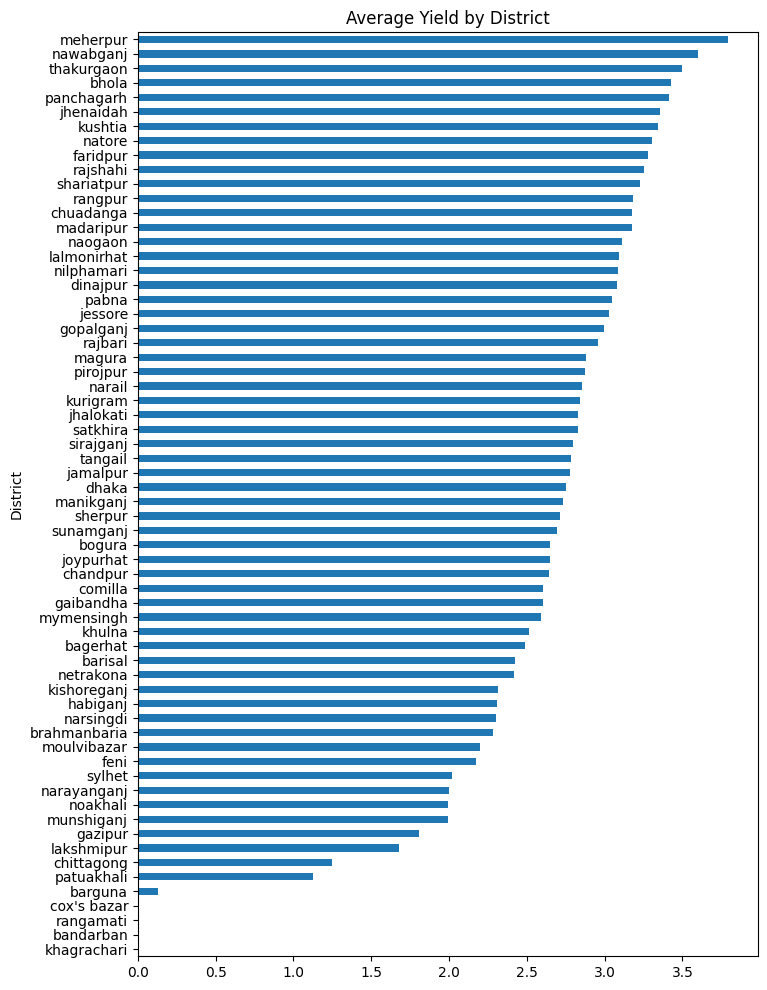

In [25]:
df_raw.groupby("District")["Yeild_Rate_Hectors_M_Ton"].mean().sort_values().plot(kind="barh", figsize=(8,12))
plt.title("Average Yield by District")
plt.show()

“I used boxplots to visualize production distribution across districts and detect extreme values.”
“I used the Interquartile Range method to identify statistically significant outliers.”
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
“I manually plotted outliers to Red points(🔴) to clearly distinguish them from normal data.”

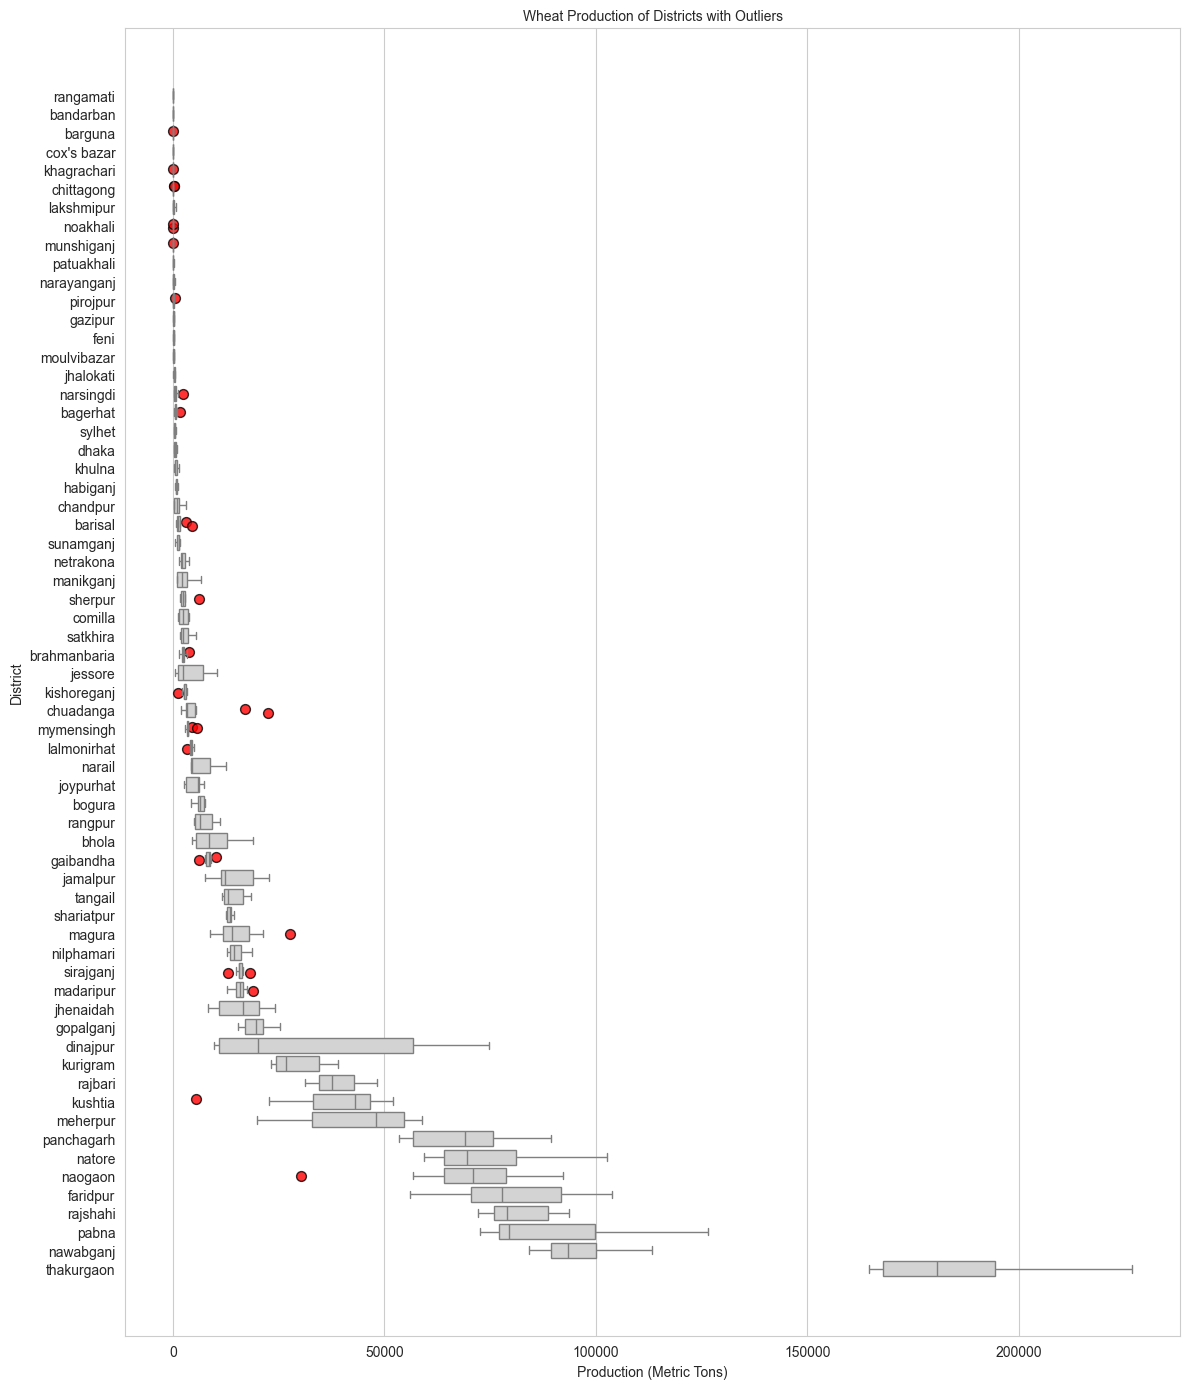

In [26]:
sns.set_style("whitegrid")
# Rank districts by median production
order = df_raw.groupby("District")["Production_M_Ton"] \
                .median().sort_values().index

plt.figure(figsize=(12, 14))

# Boxplot (no fliers)
sns.boxplot(
    data=df_raw,
    x="Production_M_Ton",
    y="District",
    order=order,
    showfliers=False,
    color="lightgray"
)

# Add outliers
for i, district in enumerate(order):
    subset = df_raw[df_raw["District"] == district]["Production_M_Ton"]
    
    q1 = subset.quantile(0.25)
    q3 = subset.quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = subset[(subset < lower) | (subset > upper)]
    
    # jitter y-position slightly to avoid clustering
    y_positions = i + np.random.uniform(-0.15, 0.15, size=len(outliers))
    
    plt.scatter(
        outliers,
        y_positions,
        color="red",
        s=50,
        alpha=0.8,
        edgecolor="black"
    )

plt.title("Wheat Production of Districts with Outliers", fontsize=10)
plt.xlabel("Production (Metric Tons)")
plt.ylabel("District")

plt.tight_layout()
plt.show()

“I computed pairwise correlations to understand relationships between climate variables and production.”
“Correlation helps in feature selection for forecasting models like SARIMA or ML models.”

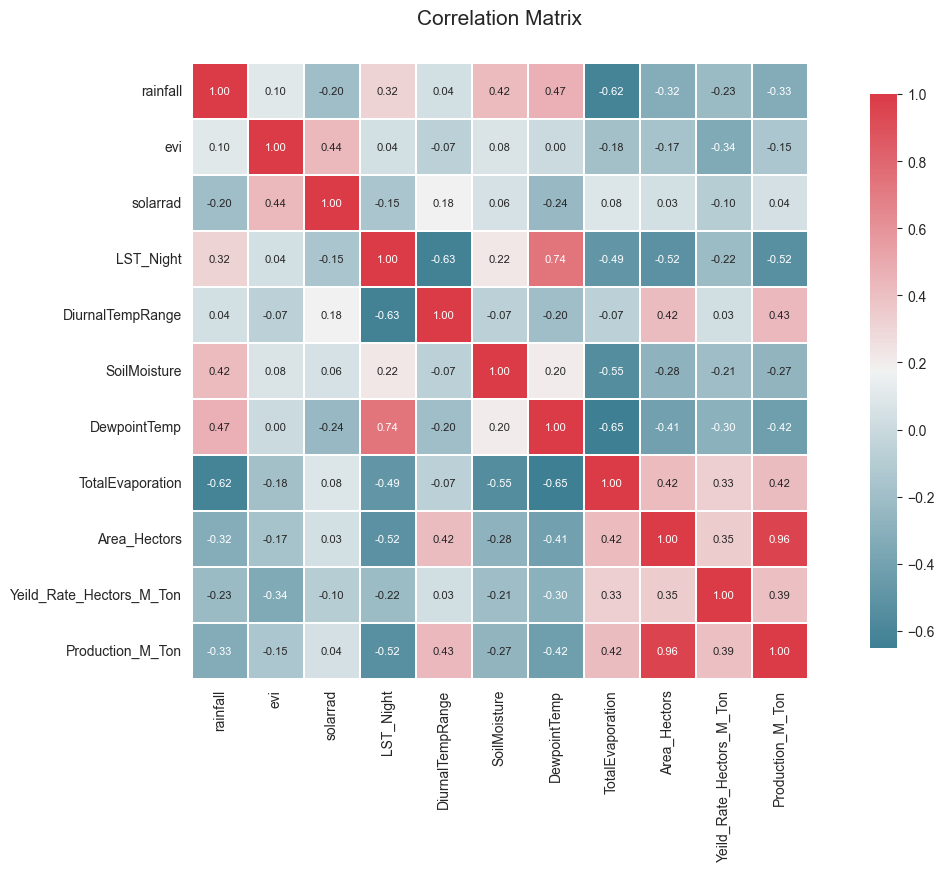

In [27]:
numeric_columns = ['rainfall','evi','solarrad','LST_Night', 
        'DiurnalTempRange','SoilMoisture','DewpointTemp','TotalEvaporation','Area_Hectors','Yeild_Rate_Hectors_M_Ton', 'Production_M_Ton']
df_numeric = df_raw[numeric_columns]

plt.figure(figsize=(16, 8))
#This line calculates the correlation matrix for the numeric columns using the corr method.                                                                                  #to control the dimensions of the heatmap.
correlation_matrix = df_numeric.corr()                                              

#sns.heatmap() function in Seaborn is used to visualize a matrix-like dataset, such as a correlation matrix.
sns.heatmap(correlation_matrix,cmap=sns.diverging_palette(220, 10, as_cmap = True), 
            annot=True,square=True, #annot=True: If True, it adds numerical annotations to each cell
            cbar_kws={'shrink':.9 }, # it specifies that the color bar should be shrunk by 10% to make it slightly smaller.                                                #cbar_kws={'shrink': .9}:Here,  
            linewidths=0.1,vmax=1.0, #linewidths=0.1: Specifies the width of the lines that will divide each cell in the heatmap.
            linecolor='white', 
            fmt=".2f", #fmt=".2f": Specifies the format for annotating the cells.                                                                
            annot_kws={'fontsize':8 }) #annot_kws={'fontsize': 8} it specifies that the font size of the annotations should be 8                                            
plt.title("Correlation Matrix",y=1.05, size=15)
plt.show()

🔑 Key insights from the heatmap:
✅ Strong positive: Area_Hectors ↔ Production (~0.96)
“Production is highly dependent on cultivated area.”

✅ Moderate relationships: Rainfall ↔ Soil Moisture (~0.42)
“Rainfall contributes to soil moisture, which affects crop growth.”

❗ Negative correlations: Evaporation ↔ Soil Moisture (~ -0.55)
“Higher evaporation reduces soil moisture.”

# Modeling

“Since this is supervised learning, I removed rows where the target variable is missing. Models cannot learn without ground truth.”

In [28]:
df_model = df_raw.dropna(subset=["Production_M_Ton"]).copy()

“I encoded district names into numeric form because machine learning models cannot handle categorical strings directly.”

In [29]:
le = LabelEncoder()
df_model["District_enc"] = le.fit_transform(df_model["District"])

“I converted year into numeric format to allow the model to capture temporal trends.”

In [30]:
df_model["Year"] = df_model["Year"].str[:4].astype(int)

“Although yield and area are mathematically related to production, I kept them because I used tree-based models, which are robust to multicollinearity. However, in linear models, I would remove one to avoid redundancy.”

In [31]:
# Define Target & Features
target = "Production_M_Ton"

features_all = [
    'Year', 'District_enc', 'rainfall', 'evi', 'solarrad',
    'LST_Night', 'DiurnalTempRange', 'SoilMoisture',
    'DewpointTemp', 'TotalEvaporation', 'Area_Hectors',
    'Yeild_Rate_Hectors_M_Ton'
]

X = df_model[features_all]
y = df_model[target]

“I used an 80-20 split to evaluate model generalization on unseen data.”

In [32]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

“Instead of relying on a single split, I used 5-fold cross-validation to get a more reliable estimate of model performance.” 
✅ R² : Measures how much variance in production is explained by the model. 
✅ MAE: Average absolute error—easy to interpret in real units (metric tons). 
✅ RMSE: Penalizes larger errors more heavily than MAE.

In [33]:
# Cross-validation Setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'
}

In [34]:
# Model 1 — Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_results = cross_validate(rf_model, X_train, y_train, cv=kf, scoring=scoring)

print("Random Forest Performance:")
print("R²:", np.mean(rf_results['test_r2']))
print("MAE:", -np.mean(rf_results['test_mae']))
print("RMSE:", -np.mean(rf_results['test_rmse']))

Random Forest Performance:
R²: 0.9631014999370244
MAE: 1676.76151357381
RMSE: 5406.688524370673


In [35]:
# Model 2 — LightGBM
lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    random_state=42
)

lgb_results = cross_validate(lgb_model, X_train, y_train, cv=kf, scoring=scoring)

print("\nLightGBM Performance:")
print("R²:", np.mean(lgb_results['test_r2']))
print("MAE:", -np.mean(lgb_results['test_mae']))
print("RMSE:", -np.mean(lgb_results['test_rmse']))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000798 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1419
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 12
[LightGBM] [Info] Start training from score 18780.584352
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [36]:
# Model 3 — XGBoost
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_results = cross_validate(xgb_model, X_train, y_train, cv=kf, scoring=scoring)

print("\nXGBoost Performance:")
print("R²:", np.mean(xgb_results['test_r2']))
print("MAE:", -np.mean(xgb_results['test_mae']))
print("RMSE:", -np.mean(xgb_results['test_rmse']))


XGBoost Performance:
R²: 0.9707317998965868
MAE: 1444.1730828302675
RMSE: 4923.674978690409


“I selected the best model based on average R² across cross-validation folds.”

In [37]:
# Select Best Model
models = {
    "Random Forest": np.mean(rf_results['test_r2']),
    "LightGBM": np.mean(lgb_results['test_r2']),
    "XGBoost": np.mean(xgb_results['test_r2'])
}

# Get the name of the model with the highest score
best_model_name = max(models, key=models.get)

# 2. Retrieve the score using the best model name
best_score = models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Best Score: {best_score}")

Best Model: XGBoost
Best Score: 0.9707317998965868


“XGBoost achieved the highest R² of 0.97, meaning it explains 97% of the variance in production, indicating very strong predictive performance.”

# Model Specification 2 (Satellite-only features)

In [38]:
satellite_features = [
    'rainfall', 'evi', 'solarrad', 'LST_Night',
    'DiurnalTempRange', 'SoilMoisture',
    'DewpointTemp', 'TotalEvaporation'
]

# “Here I am selecting only the satellite-derived features as input variables (X), isolating them from other possible predictors.”
X_sat = df_model[satellite_features]

sat_results = cross_validate(xgb_model, X_sat, y, cv=kf, scoring=scoring)

print("\nSatellite-only Model (XGBoost):")
print("R²:", np.mean(sat_results['test_r2']))
print("MAE:", -np.mean(sat_results['test_mae']))
print("RMSE:", -np.mean(sat_results['test_rmse']))


Satellite-only Model (XGBoost):
R²: 0.3332095977548887
MAE: 15115.933642473818
RMSE: 26606.468697962893


# Feature Importance (Tree-based)

                     Feature  Importance
10              Area_Hectors    0.617717
1               District_enc    0.352641
3                        evi    0.009808
11  Yeild_Rate_Hectors_M_Ton    0.007264
0                       Year    0.005758
6           DiurnalTempRange    0.002445
9           TotalEvaporation    0.001968
7               SoilMoisture    0.000862
5                  LST_Night    0.000670
8               DewpointTemp    0.000421
2                   rainfall    0.000356
4                   solarrad    0.000091


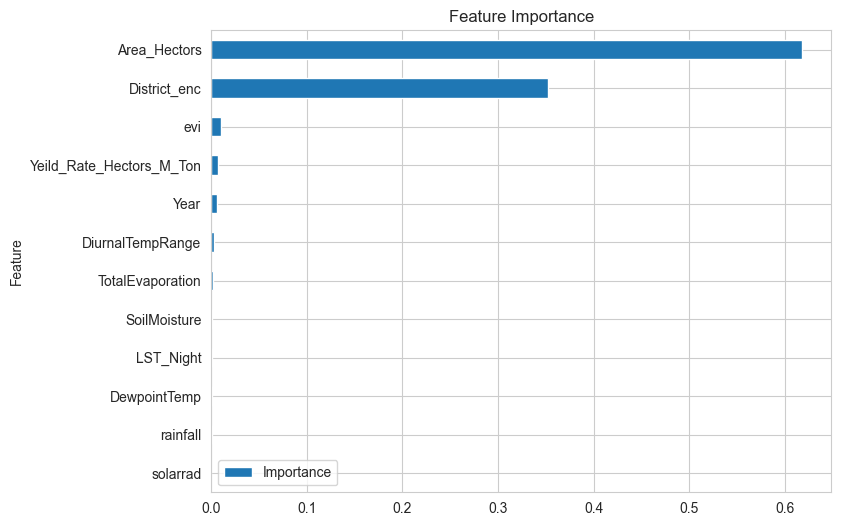

In [39]:
best_model = xgb_model  # replace if another wins
best_model.fit(X_train, y_train)

importances = best_model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

# Plot
feat_imp.plot(kind='barh', x='Feature', y='Importance', figsize=(8,6))
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

# SHAP Values (Interpretability)

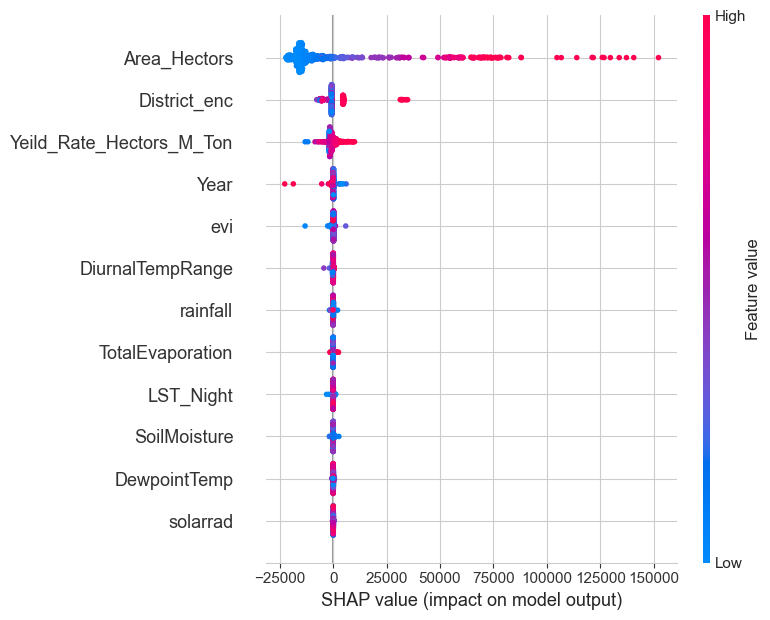

In [40]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(df_model[features_all])

# Summary plot
shap.summary_plot(shap_values, df_model[features_all])

# Forecast

In [41]:
# Use df_model from Task 1
df_model = df_model.sort_values(["District", "Year"]).copy()

In [42]:
# Get last available observation per district
last_data = df_model.groupby("District").tail(1).copy()

In [43]:
def forecast_next_year(df_last, model, features):
    df_pred = df_last.copy()
    
    # Predict production
    df_pred["Predicted_Production"] = model.predict(df_pred[features])
    
    return df_pred

In [44]:
forecast_2025 = forecast_next_year(last_data, best_model, features_all)
forecast_2025["Year"] = "2024-2025"

In [45]:
forecast_df = forecast_2025[
    ["District", "Year", "Predicted_Production"]
].sort_values("Predicted_Production", ascending=False)

print(forecast_df.head(10))
print(forecast_df.shape)

       District       Year  Predicted_Production
638  thakurgaon  2024-2025         151338.312500
626      natore  2024-2025         102525.546875
627   nawabganj  2024-2025         101301.445312
629    rajshahi  2024-2025          88411.453125
628       pabna  2024-2025          86733.203125
636  panchagarh  2024-2025          73303.250000
593    faridpur  2024-2025          72270.609375
616    meherpur  2024-2025          58933.613281
605     rajbari  2024-2025          38908.175781
625     naogaon  2024-2025          30343.654297
(64, 3)


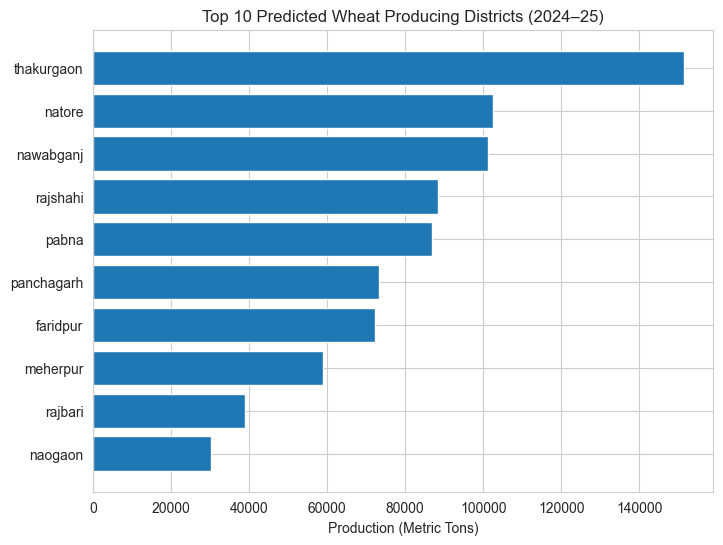

In [46]:
top10 = forecast_df.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10["District"], top10["Predicted_Production"])
plt.gca().invert_yaxis()
plt.title("Top 10 Predicted Wheat Producing Districts (2024–25)")
plt.xlabel("Production (Metric Tons)")
plt.show()

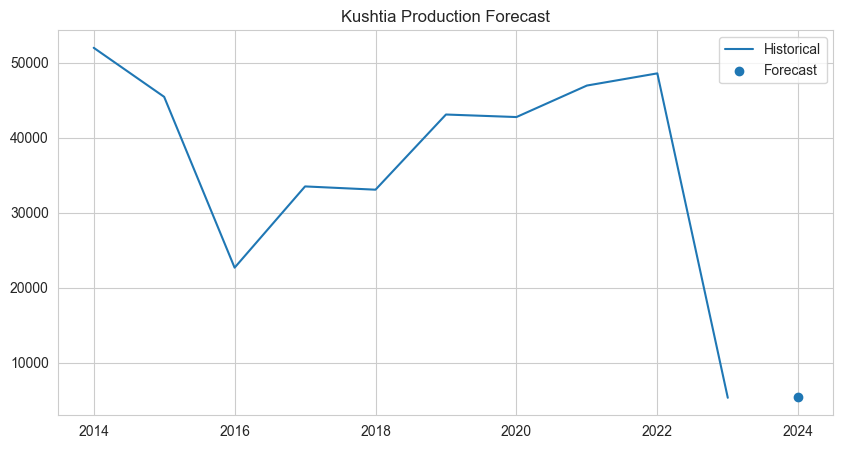

In [47]:
district = "kushtia"

hist = df_model[df_model["District"] == district]

plt.figure(figsize=(10,5))
plt.plot(hist["Year"], hist["Production_M_Ton"], label="Historical")

pred_val = forecast_df[forecast_df["District"] == district]["Predicted_Production"].values[0]

plt.scatter(2024, pred_val, label="Forecast", marker='o')

plt.title(f"{district.title()} Production Forecast")
plt.legend()
plt.show()

# HTML Forecast Map

In [67]:
# Importings 
import geopandas as gpd
import folium

In [68]:
# LOAD SHAPEFILE (GeoPandas)
shp_path = "gadm41_BGD_2.shp"
gdf = gpd.read_file(shp_path)

gdf.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,BGD.1.1_1,BGD,Bangladesh,BGD.1_1,Barisal,NA,Barguna,NA,NA,Zila,Distict,1004,BD.BA.PR,"MULTIPOLYGON (((89.98476 21.9577, 89.98483 21...."
1,BGD.1.2_1,BGD,Bangladesh,BGD.1_1,Barisal,NA,Barisal,NA,NA,Zila,Distict,1006,BD.BA.PR,"MULTIPOLYGON (((90.43166 22.49055, 90.43195 22..."
2,BGD.1.3_1,BGD,Bangladesh,BGD.1_1,Barisal,NA,Bhola,NA,NA,Zila,Distict,1009,BD.BA.PR,"MULTIPOLYGON (((90.81534 21.88569, 90.81492 21..."
3,BGD.1.4_1,BGD,Bangladesh,BGD.1_1,Barisal,NA,Jhalokati,NA,NA,Zila,Distict,1042,BD.BA.PR,"POLYGON ((90.10083 22.35833, 90.10042 22.35875..."
4,BGD.1.5_1,BGD,Bangladesh,BGD.1_1,Barisal,NA,Patuakhali,NA,NA,Zila,Distict,1078,BD.BA.PR,"MULTIPOLYGON (((90.45658 21.80762, 90.45665 21..."


In [69]:
# CHECK DISTRICT COLUMN
gdf.columns

Index(['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2',
       'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2',
       'geometry'],
      dtype='object')

In [70]:
gdf[['NAME_2']].head()

,NAME_2
0,Barguna
1,Barisal
2,Bhola
3,Jhalokati
4,Patuakhali


In [71]:
forecast_df.head()

,District,Year,Predicted_Production
638,thakurgaon,2024-2025,151338.312500
626,natore,2024-2025,102525.546875
627,chapainawabganj,2024-2025,101301.445312
629,rajshahi,2024-2025,88411.453125
628,pabna,2024-2025,86733.203125


In [72]:
# We must match naming:
forecast_df['District'] = forecast_df['District'].str.lower()
gdf['NAME_2'] = gdf['NAME_2'].str.lower()

In [73]:
# Fixing inconsistencies like spelling mismatches
corrections = {
    "bogra": "bogura",
    "brahamanbaria": "brahmanbaria",
    "khagrachhari": "khagrachari",
    "maulvibazar": "moulvibazar",
    "maulavibazar": "moulvibazar",
    "nawabganj": "chapainawabganj"  # standard name
}

gdf["NAME_2"] = gdf["NAME_2"].replace(corrections)
forecast_df["District"] = forecast_df["District"].replace(corrections)

In [74]:
set(forecast_df["District"]) - set(gdf["NAME_2"])

set()

In [75]:
print(gdf["NAME_2"].nunique())

64


In [76]:
print(forecast_df["District"].nunique())

64


In [77]:
# FILTER ONE YEAR
map_df = forecast_df[forecast_df['Year'] == 2024]

In [78]:
# MERGE DATA
merged = gdf.merge(
    forecast_df,
    left_on='NAME_2',
    right_on='District',
    how='left'
)

In [79]:
merged.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   GID_2                 64 non-null     object  
 1   GID_0                 64 non-null     object  
 2   COUNTRY               64 non-null     object  
 3   GID_1                 64 non-null     object  
 4   NAME_1                64 non-null     object  
 5   NL_NAME_1             64 non-null     object  
 6   NAME_2                64 non-null     object  
 7   VARNAME_2             64 non-null     object  
 8   NL_NAME_2             64 non-null     object  
 9   TYPE_2                64 non-null     object  
 10  ENGTYPE_2             64 non-null     object  
 11  CC_2                  64 non-null     object  
 12  HASC_2                64 non-null     object  
 13  geometry              64 non-null     geometry
 14  District              64 non-null     object  
 15  

In [80]:
# CREATE INTERACTIVE FOLIUM MAP
m = folium.Map(location=[23.7, 90.4], zoom_start=7)

In [81]:
# Choropleth
folium.Choropleth(
    geo_data=merged,
    data=merged,
    columns=['NAME_2', 'Predicted_Production'],
    key_on='feature.properties.NAME_2',
    fill_color='YlGnBu',
    fill_opacity=0.8,
    line_opacity=0.3,
    legend_name='Predicted Production (2024)'
).add_to(m)

In [82]:
# ADD HOVER TOOLTIP
folium.GeoJson(
    merged,
    tooltip=folium.GeoJsonTooltip(
        fields=['NAME_2', 'Predicted_Production'],
        aliases=['District:', 'Predicted Production:'],
        localize=True
    )
).add_to(m)

In [83]:
# SAVE INTERACTIVE HTML
m.save("bangladesh_Wheat_production_forecast_2024.html")